--Benchmarking Machine Learning Against Physics-Based Proton Range Prediction Under RSP Uncertainty--

This notebook implements a simplified one-dimensional proton transport model and compares it with machine-learning approaches for proton range prediction under relative stopping power (RSP) uncertainty.

The workflow consists of:

1. Loading proton stopping-power data from the NIST PSTAR database.
2. Implementing a stepwise proton transport model.
3. Validating the transport model in homogeneous water.
4. Generating heterogeneous synthetic RSP profiles.
5. Introducing controlled RSP uncertainty.
6. Comparing physics-based range prediction with Linear Regression and Random Forest models.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

1. NIST PSTAR stopping-power data

Proton stopping powers were obtained from the NIST PSTAR database for liquid water.

The transport calculation uses the total mass stopping power as a function of proton kinetic energy. Because the PSTAR energy grid spans several orders of magnitude, stopping power is interpolated in log-energy/log-stopping-power space.

In [39]:
nist_full = pd.read_csv("../data/nist_water_full.txt",sep=r"\s+",skiprows=8,
    header=None,names=["energy_mev","stopping_electronic","stopping_nuclear",
        "stopping_total","range_csda","range_projected","detour_factor"])

print(f"Number of PSTAR entries: {len(nist_full)}")
print(f"Energy range: {nist_full['energy_mev'].min()}–{nist_full['energy_mev'].max()} MeV")

nist_full.head()

Number of PSTAR entries: 132
Energy range: 0.001–10000.0 MeV


,energy_mev,stopping_electronic,stopping_nuclear,stopping_total,range_csda,range_projected,detour_factor
0,0.0010,133.7,43.15,176.9,0.000006,0.000003,0.4555
1,0.0015,163.8,34.60,198.4,0.000009,0.000004,0.4906
2,0.0020,189.1,29.27,218.4,0.000011,0.000006,0.5197
3,0.0025,211.4,25.57,237.0,0.000014,0.000007,0.5440
4,0.0030,231.6,22.81,254.4,0.000016,0.000009,0.5647


Log-log stopping-power interpolation

The tabulated PSTAR stopping powers are interpolated according to $\log S = f(\log E)$, where $E$ is the proton kinetic energy and $S$ is the total mass stopping power in water. 

In [40]:
log_energy=np.log(nist_full["energy_mev"].values)
log_stopping=np.log(nist_full["stopping_total"].values)

#Interpolate the total proton stopping power in water
def stopping_power_water(energy_mev):
    energy_mev = np.asarray(energy_mev)
    log_E=np.log(energy_mev)
    log_S=np.interp(log_E, log_energy, log_stopping)

    return np.exp(log_S)

In [41]:
interpolated_values=stopping_power_water(nist_full["energy_mev"].values)

relative_error=(np.abs(interpolated_values - nist_full["stopping_total"].values)
    /nist_full["stopping_total"].values)

print("Maximum relative interpolation error:",relative_error.max())

print("Mean relative interpolation error:",relative_error.mean())

Maximum relative interpolation error: 5.112584517536323e-16
Mean relative interpolation error: 1.4526202440083098e-16


2. Physics-based proton transport

Proton transport is modelled using a simplified one-dimensional continuous slowing-down approximation.

At each spatial step, $E_{i+1}=E_i-S_{\mathrm{water}}(E_i)
\,\mathrm{RSP}_i
\,\Delta z .
$

Here, $S_{\mathrm{water}}(E)$ is the proton mass stopping power in water, $\mathrm{RSP}_i$ is the relative stopping power of the material at the current depth, and $\Delta z$ is the spatial step.

Liquid water density is approximated as $1\,\mathrm{g\,cm^{-3}}$, allowing the PSTAR mass stopping power to be used with depth in centimetres in this simplified model.


In [42]:
#Calculate proton stopping distance through an RSP profile
def proton_range_transport(initial_energy, rsp_profile, dz):
    energy=initial_energy

    for i, rsp in enumerate(rsp_profile):
        if energy <=0:
            return i*dz
        stopping=stopping_power_water(energy)
        energy_loss=stopping*rsp*dz
        energy-= energy_loss

    return len(rsp_profile)*dz


In [43]:
#Track proton kinetic energy as a function of depth
def track_proton(initial_energy, rsp_profile, dz):
    energy=initial_energy
    energies=[energy]
    
    for rsp in rsp_profile:
        if energy<=0:
            energies.append(0.0)
            continue
        stopping=stopping_power_water(energy)
        energy_loss=stopping*rsp*dz
        energy-=energy_loss
        energy=max(energy, 0.0) #in case negative
        energies.append(energy)

    return np.array(energies)

Validation in homogeneous water

The transport model is first tested for a 150 MeV proton in homogeneous water.

The predicted stopping range is compared with the corresponding NIST PSTAR CSDA range. The calculation is repeated with decreasing spatial step size to check numerical convergence.

In [44]:
nist_range_150 = float(nist_full.loc[np.isclose(nist_full["energy_mev"], 150),
        "range_csda"].iloc[0])

print(f"NIST CSDA range at 150 MeV: {nist_range_150:.3f} cm\n")

for dz_test in [0.1, 0.05, 0.01]:

    n_bins_test=int(20/dz_test)
    water_profile=np.ones(n_bins_test)

    calculated_range = proton_range_transport(initial_energy=150,rsp_profile=water_profile,
        dz=dz_test)

    absolute_error=abs(calculated_range-nist_range_150)

    relative_error=(absolute_error/nist_range_150 * 100)

    print(f"dz = {dz_test:.2f} cm | range = {calculated_range:.3f} cm | absolute error = {absolute_error:.3f} cm | relative error = {relative_error:.2f}%")

NIST CSDA range at 150 MeV: 15.770 cm

dz = 0.10 cm | range = 16.000 cm | absolute error = 0.230 cm | relative error = 1.46%
dz = 0.05 cm | range = 15.900 cm | absolute error = 0.130 cm | relative error = 0.82%
dz = 0.01 cm | range = 15.800 cm | absolute error = 0.030 cm | relative error = 0.19%


The calculated range converges toward the NIST CSDA value as the spatial step is reduced.

A step size of $\Delta z = 0.1$ cm is used for the synthetic dataset as a compromise between numerical resolution and computational cost.

3. Synthetic heterogeneous RSP profiles

Synthetic one-dimensional tissue profiles are generated to represent simplified heterogeneous patient geometries.

Each profile has a total depth of 40 cm and contains between three and five tissue segments. Representative relative stopping power values are used for:

- Lung: RSP=0.3
- Soft tissue: RSP=1.0
- Bone: RSP=1.6

The proton beam energy is randomly selected from 100, 125, 150, 175, or 200 MeV.

In [45]:
#Experiment configuration
dz=0.1
n_bins=400
total_depth=n_bins*dz

energy_values=[100,125,150,175,200] #proton energies

RSP_SOFT=1.0
RSP_LUNG=0.3
RSP_BONE=1.6

N_SAMPLES=1000 #dataset size
print(f"Geometry depth: {total_depth:.1f} cm")
print(f"Spatial resolution: {dz:.1f} cm")
print(f"Number of bins: {n_bins}")
print(f"Beam energies: {energy_values} MeV")

Geometry depth: 40.0 cm
Spatial resolution: 0.1 cm
Number of bins: 400
Beam energies: [100, 125, 150, 175, 200] MeV


In [46]:
#Generate a heterogeneous 1D RSP profile
def generate_rsp_profile(rng, n_bins=400):
    profile=np.ones(n_bins)
    n_segments=rng.integers(3,6) #choose between 3-5 tissue segments

    boundaries=np.sort(rng.choice(np.arange(20, n_bins-20), size=n_segments-1, replace=False)) #select internal segment boundaries

    boundaries=np.concatenate([[0], boundaries, [n_bins]]) #to join the sequence of arrays along existing axis

    tissue_values=[RSP_SOFT, RSP_LUNG, RSP_BONE]
    tissues=tissue_values.copy() #ensure each basic tissue type appears at least once

    #fill remaining segments randomly
    if n_segments>3:
        tissues.extend(rng.choice(tissue_values, size=n_segments-3, replace=True))

    tissues=rng.permutation(tissues) #shuffle the tissue order

    for i in range(n_segments):
        start=boundaries[i]
        end=boundaries[i+1]
        profile[start:end]=tissues[i]

    return profile

Example heterogeneous profile

The following example illustrates the type of synthetic RSP geometry used in the study.

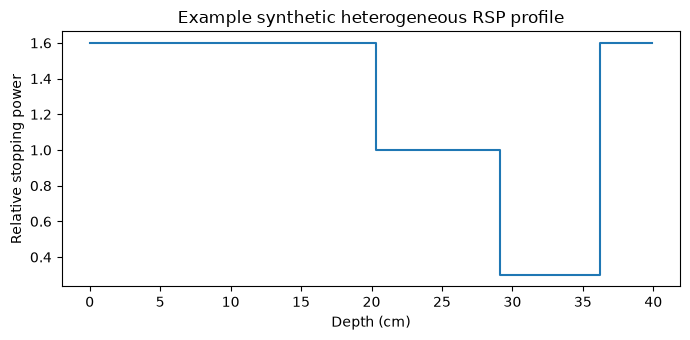

In [47]:
rng_example=np.random.default_rng(1)

example_rsp = generate_rsp_profile(rng_example,n_bins=n_bins)
depth = np.arange(n_bins) * dz

plt.figure(figsize=(7, 3.5))
plt.step(depth,example_rsp,where="post")
plt.xlabel("Depth (cm)")
plt.ylabel("Relative stopping power")
plt.title("Example synthetic heterogeneous RSP profile")
plt.tight_layout()
plt.show()

4. RSP uncertainty model

To represent uncertainty in the estimated stopping-power profile, multiplicative Gaussian noise is applied:

$\mathrm{RSP}_{\mathrm{noisy}}=\mathrm{RSP}_{\mathrm{true}}(1+\epsilon)$

where

$\epsilon \sim \mathcal{N}(0,\sigma)$.

Three uncertainty levels are considered: $\sigma = 0,\ 0.02,\ 0.05$, corresponding to 0%, 2%, and 5% RSP noise.

In [48]:
#Add multiplicative Gaussian uncertainty to an RSP profile
def add_rsp_noise(rsp_profile, noise_level, rng):
    noise=rng.normal(loc=0.0, scale=noise_level, size=len(rsp_profile))
    noisy_profile=rsp_profile*(1+noise)

    return noisy_profile

5. Dataset generation

For each simulated case:

1. An initial proton energy is selected.
2. A heterogeneous true RSP profile is generated.
3. Gaussian RSP noise is applied.
4. The true proton range is calculated from the clean RSP profile.
5. The physics-based prediction is calculated from the noisy RSP profile.

Cases in which the proton does not stop within the 40 cm geometry are excluded.

This ensures that every retained sample has a well-defined stopping range within the simulated domain.

In [49]:
#Generate a synthetic proton-range dataset
def create_dataset(n_samples,noise_level,rng):
    dataset=[]

    while len(dataset)<n_samples:
        initial_energy = rng.choice(energy_values).item()
        true_rsp = generate_rsp_profile(rng,n_bins=n_bins)

        noisy_rsp = add_rsp_noise(true_rsp,noise_level=noise_level,rng=rng)
        true_range = proton_range_transport(initial_energy,true_rsp,dz)

        #Exclude cases that do not stop inside the simulated geometry
        if true_range>=total_depth:
            continue

        physics_range = proton_range_transport(initial_energy,noisy_rsp,dz)

        dataset.append({"initial_energy": initial_energy,"true_rsp": true_rsp,
                        "noisy_rsp": noisy_rsp,"true_range": true_range,
                        "physics_range": physics_range})

    return dataset

6. Machine-learning features

The machine-learning models do not receive the complete spatial RSP profile.

Instead, each simulated case is represented using five global features:

- Initial proton energy
- Water-equivalent thickness (WET)
- Standard deviation of the noisy RSP profile
- Approximate lung fraction
- Approximate bone fraction

The physics-based prediction is retained for benchmarking only and is not used as an ML input feature.

In [50]:
#Convert simulated cases into an ML feature table
def extract_features(dataset):
    rows=[]

    for case in dataset:
        noisy_rsp=case["noisy_rsp"]
        wet=np.sum(noisy_rsp) * dz
        std_rsp=np.std(noisy_rsp)

        lung_fraction=np.mean(noisy_rsp < 0.6)
        bone_fraction=np.mean(noisy_rsp > 1.3)

        rows.append({"initial_energy":case["initial_energy"],"wet":wet,
                     "std_rsp":std_rsp,"lung_fraction":lung_fraction,
                     "bone_fraction":bone_fraction,"physics_range":case["physics_range"],
                     "true_range":case["true_range"]})

    return pd.DataFrame(rows)

7. Generate the three noise datasets

Independent synthetic datasets are generated for the three tested RSP uncertainty levels.

Fixed random seeds are used so that the experiments can be reproduced.

In [51]:
noise_settings={0.00: 123, 0.02: 456, 0.05: 789,}
datasets={}

for noise_level, seed in noise_settings.items():
    rng = np.random.default_rng(seed)
    datasets[noise_level] = create_dataset(n_samples=N_SAMPLES,noise_level=noise_level,
                                           rng=rng)

    print(f"{noise_level * 100:.0f}% noise: {len(datasets[noise_level])} samples")

0% noise: 1000 samples
2% noise: 1000 samples
5% noise: 1000 samples


In [52]:
#Convert to dataframes
dataframes={}
for noise_level, dataset in datasets.items():
    dataframes[noise_level] = extract_features(dataset)
    print(f"{noise_level * 100:.0f}% noise: {dataframes[noise_level].shape}")

0% noise: (1000, 7)
2% noise: (1000, 7)
5% noise: (1000, 7)


In [53]:
#Inspect one dataset
dataframes[0.05].head()

,initial_energy,wet,std_rsp,lung_fraction,bone_fraction,physics_range,true_range
0,150,38.526690,0.330318,0.140,0.1025,17.4,17.4
1,100,38.066161,0.355457,0.170,0.1200,7.9,7.9
2,175,56.265055,0.295148,0.005,0.6900,17.8,17.8
3,175,40.566072,0.596980,0.380,0.4750,13.1,13.1
4,175,34.899582,0.479110,0.350,0.1900,26.3,26.2


In [54]:
#Sanity checks
for noise_level, df in dataframes.items():
    print(f"\n--- {noise_level * 100:.0f}% noise ---")
    print(f"True range: {df['true_range'].min():.1f}–{df['true_range'].max():.1f} cm")
    print(f"Physics range: {df['physics_range'].min():.1f}–{df['physics_range'].max():.1f} cm")


--- 0% noise ---
True range: 5.0–39.9 cm
Physics range: 5.0–39.9 cm

--- 2% noise ---
True range: 5.0–39.9 cm
Physics range: 5.0–39.9 cm

--- 5% noise ---
True range: 5.0–39.3 cm
Physics range: 4.9–39.6 cm


All generated cases stop within the simulated 40 cm geometry.

The resulting feature tables will now be used to train and evaluate the Linear Regression and Random Forest models. The physics-based prediction will serve as the reference benchmark.

8. Machine-learning models

Two regression models are used:

- Linear Regression
- Random Forest Regression

Both models receive the same five summary features derived from the noisy RSP profile.

The complete spatial RSP profile and the physics-based range prediction are not provided to the machine-learning models.

In [55]:
features=['initial_energy', 'wet', 'std_rsp', 'lung_fraction','bone_fraction']
target='true_range'
random_state=42

print('Machine learning features:')
for feature in features:
    print(f"- {feature}")

Machine learning features:
- initial_energy
- wet
- std_rsp
- lung_fraction
- bone_fraction


Train-test split

For each noise level, 80% of the simulated cases are used for training and 20% are reserved for testing.

The same test cases are used to evaluate Linear Regression, Random Forest and the physics-based baseline within each noise condition.

In [56]:
#Train Linear Regression and Random Forest models
def train_models(df):
    X=df[features]
    y=df[target]
    X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,
                                                        random_state=random_state)

    #Linear Regression
    linear_model=LinearRegression()
    linear_model.fit(X_train,y_train)
    linear_predictions=linear_model.predict(X_test)

    #Random Forest
    rf_model=RandomForestRegressor(n_estimators=200,random_state=random_state,
                                   n_jobs=-1)
    rf_model.fit(X_train,y_train)
    rf_predictions= rf_model.predict(X_test)

    #Physics prediction for the same test cases
    physics_predictions= df.loc[X_test.index,"physics_range",].values

    return {"X_train": X_train,"X_test": X_test,"y_train": y_train,
            "y_test": y_test,"linear_model": linear_model,"rf_model": rf_model,
            "linear_predictions": linear_predictions,"rf_predictions": rf_predictions,
            "physics_predictions": physics_predictions}

In [57]:
#Train all three experiments
model_outputs={}

for noise_level, df in dataframes.items():
    model_outputs[noise_level]=train_models(df)
    print(f"{noise_level * 100:.0f}% noise: {len(model_outputs[noise_level]['y_train'])} training cases, {len(model_outputs[noise_level]['y_test'])} test cases")

0% noise: 800 training cases, 200 test cases
2% noise: 800 training cases, 200 test cases
5% noise: 800 training cases, 200 test cases


9. Performance metrics

Model performance is evaluated using:

- Mean absolute error (MAE)
- Root mean squared error (RMSE)
- Coefficient of determination ($R^2$)
- Maximum absolute error

All range errors are reported in centimetres.

In [58]:
#Calculate regression performance metrics
def calculate_metrics(y_true, y_pred):
    errors=np.asarray(y_pred)-np.asarray(y_true)
    return {"MAE (cm)": mean_absolute_error(y_true,y_pred),
            "RMSE (cm)": np.sqrt(mean_squared_error(y_true,y_pred)),
            "R²": r2_score(y_true,y_pred),
            "Max |error| (cm)": np.max(np.abs(errors))}

In [59]:
#Construct the results table
results_rows=[]

for noise_level, output in model_outputs.items():
    y_test=output["y_test"]
    predictions={"Physics baseline":output["physics_predictions"],
                   "Linear Regression":output["linear_predictions"],
                   "Random Forest":output["rf_predictions"]}

    for model_name, y_pred in predictions.items():
        metrics=calculate_metrics(y_test,y_pred)
        results_rows.append({"Noise (%)":int(noise_level * 100),
                              "Model":model_name,**metrics})

results=pd.DataFrame(results_rows)

results

,Noise (%),Model,MAE (cm),RMSE (cm),R²,Max |error| (cm)
0,0,Physics baseline,0.000000,0.000000,1.000000,0.000000
1,0,Linear Regression,4.155271,5.148767,0.624570,12.135057
2,0,Random Forest,4.321244,5.485479,0.573861,19.700500
3,2,Physics baseline,0.018500,0.045277,0.999977,0.200000
4,2,Linear Regression,4.511044,5.450745,0.665398,13.064996
5,2,Random Forest,4.386563,5.793471,0.621998,20.926500
6,5,Physics baseline,0.057000,0.095394,0.999877,0.500000
7,5,Linear Regression,4.131877,5.051880,0.655545,12.419727
8,5,Random Forest,4.139033,5.367524,0.611157,17.987000


In [60]:
#Clean display of the results
results_display=results.copy()

results_display[["MAE (cm)","RMSE (cm)","R²","Max |error| (cm)"]]=results_display[["MAE (cm)",
                                                                                   "RMSE (cm)",
                                                                                   "R²",
                                                                                   "Max |error| (cm)"]].round(3)

results_display

,Noise (%),Model,MAE (cm),RMSE (cm),R²,Max |error| (cm)
0,0,Physics baseline,0.000,0.000,1.000,0.000
1,0,Linear Regression,4.155,5.149,0.625,12.135
2,0,Random Forest,4.321,5.485,0.574,19.701
3,2,Physics baseline,0.018,0.045,1.000,0.200
4,2,Linear Regression,4.511,5.451,0.665,13.065
5,2,Random Forest,4.387,5.793,0.622,20.926
6,5,Physics baseline,0.057,0.095,1.000,0.500
7,5,Linear Regression,4.132,5.052,0.656,12.420
8,5,Random Forest,4.139,5.368,0.611,17.987


Interpretation

The physics-based calculation provides a benchmark that retains the full spatial RSP profile.

In contrast, the machine-learning models receive only five global summary features. Their performance therefore reflects both the predictive capability of the models and the information lost when the spatial profile is reduced to a small feature set.

10. Effect of RSP uncertainty

The following analysis compares model performance across 0%, 2%, and 5% RSP uncertainty.

In [61]:
mae_table = results.pivot(index="Noise (%)",columns="Model",values="MAE (cm)")
mae_table.round(3)

Model,Linear Regression,Physics baseline,Random Forest
Noise (%),,,
0,4.155,0.000,4.321
2,4.511,0.018,4.387
5,4.132,0.057,4.139


The physics-based model is expected to remain highly accurate under the tested RSP perturbations because it retains the full spatial structure of the profile.

The machine-learning models exhibit substantially larger errors. In particular, non-zero ML error at 0% RSP noise indicates that the main limitation is not measurement noise alone. The reduced global feature representation also discards information about the spatial ordering and location of tissues.

11. Visual comparison of model performance

The following figures summarise the behaviour of the physics-based and machine-learning approaches.

The 5% RSP uncertainty condition is used for detailed prediction and error visualisations because it represents the largest perturbation considered in this study.

In [62]:
#Choose representative case
dataset_5=datasets[0.05]
target_range=20.0

representative_index=np.argmin([abs(case["true_range"]-target_range)
        for case in dataset_5])
representative_case=dataset_5[representative_index]

print(f"Case index: {representative_index}")
print(f"Initial energy: {representative_case['initial_energy']} MeV")
print(f"True range: {representative_case['true_range']:.2f} cm")
print(f"Physics-predicted range: {representative_case['physics_range']:.2f} cm")

Case index: 95
Initial energy: 100 MeV
True range: 20.00 cm
Physics-predicted range: 20.00 cm


In [ ]:
#Calculate energy trajectory
true_rsp=representative_case["true_rsp"]
noisy_rsp=representative_case["noisy_rsp"]

initial_energy=representative_case["initial_energy"]
true_range=representative_case["true_range"]
physics_range=representative_case["physics_range"]
energy_trajectory=track_proton(initial_energy,noisy_rsp,dz)
depth_energy=(np.arange(len(energy_trajectory))* dz)

In [86]:
# Plot style used for report figures
plt.rcParams.update({"font.family": "serif","font.size": 10,"axes.labelsize": 10,
                     "legend.fontsize": 9,"xtick.labelsize": 9,"ytick.labelsize": 9,
                     "figure.dpi": 120,"savefig.dpi": 300})

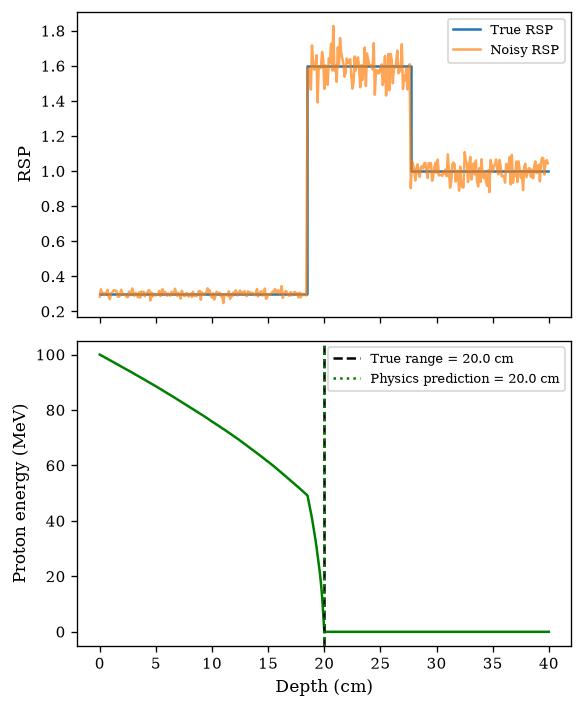

In [79]:
#Figure 1
fig, axes = plt.subplots(2,1,figsize=(5, 6),sharex=True)

#RSP profile
axes[0].step(depth,true_rsp,where="post",label="True RSP")
axes[0].plot(depth,noisy_rsp,alpha=0.7,label="Noisy RSP",)
axes[0].set_ylabel("RSP")
axes[0].legend()

#Proton energy
axes[1].plot(depth_energy,energy_trajectory, color='green')
axes[1].axvline(true_range,linestyle="--",label=f"True range = {true_range:.1f} cm",  color='black')
axes[1].axvline(physics_range,linestyle=":",label=(f"Physics prediction = {physics_range:.1f} cm"),  color='green')
axes[1].set_xlabel("Depth (cm)")
axes[1].set_ylabel("Proton energy (MeV)")
axes[1].legend()

#fig.suptitle("Example proton transport calculation at 5% RSP uncertainty")
plt.tight_layout()
plt.savefig("../figures/figure_1_transport.png",bbox_inches="tight")
plt.show()

Figure 1. Example one-dimensional proton transport calculation at 5% RSP uncertainty. The upper panel compares the true and noisy heterogeneous RSP profiles. The lower panel shows the corresponding proton energy loss with depth and the true and physics-predicted stopping ranges.

In [65]:
#MAE vs noise
noise_levels=[0, 2, 5]
physics_mae=[]
linear_mae=[]
rf_mae=[]

for noise in noise_levels:
    subset=results[results["Noise (%)"] == noise]
    physics_mae.append(subset.loc[subset["Model"]=="Physics baseline","MAE (cm)"].iloc[0])
    linear_mae.append(subset.loc[subset["Model"]=="Linear Regression","MAE (cm)"].iloc[0])
    rf_mae.append(subset.loc[subset["Model"]=="Random Forest","MAE (cm)"].iloc[0])

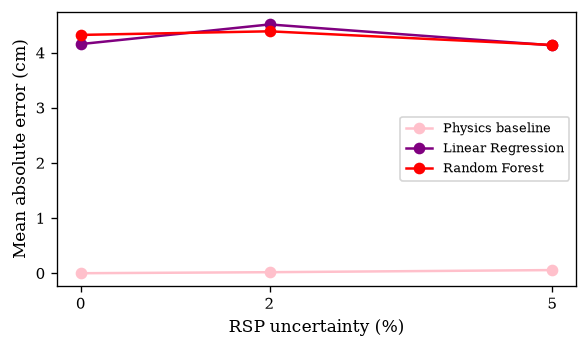

In [83]:
#Figure 2
plt.figure(figsize=(5, 3))
plt.plot(noise_levels,physics_mae,marker="o",label="Physics baseline",color='pink')
plt.plot(noise_levels,linear_mae,marker="o",label="Linear Regression",color='purple')
plt.plot(noise_levels,rf_mae,marker="o",label="Random Forest",color='red')

plt.xlabel("RSP uncertainty (%)")
plt.ylabel("Mean absolute error (cm)")
plt.xticks(noise_levels)
plt.legend()
plt.tight_layout()
plt.savefig("../figures/figure_2_mae_vs_noise.png",bbox_inches="tight")
plt.show()

Figure 2. Mean absolute error as a function of RSP uncertainty. The physics-based model remains highly accurate across all tested noise levels, whereas both machine-learning models show errors of approximately 4–4.5 cm.

In [67]:
#Predicted vs true range
#Get 5% test results
output_5=model_outputs[0.05]
y_test_5=output_5["y_test"]
linear_pred_5=output_5["linear_predictions"]
physics_pred_5 = output_5["physics_predictions"]

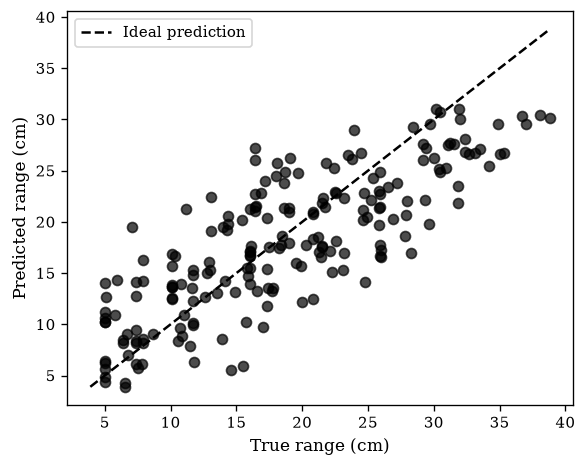

In [87]:
#Fifure 3
plt.figure(figsize=(5, 4))
plt.scatter(y_test_5,linear_pred_5,alpha=0.7, color='black')
plot_min=min(y_test_5.min(),linear_pred_5.min())
plot_max=max(y_test_5.max(),linear_pred_5.max())
plt.plot([plot_min, plot_max],[plot_min, plot_max],linestyle="--",
         label="Ideal prediction", color='black')

plt.xlabel("True range (cm)")
plt.ylabel("Predicted range (cm)")
#plt.title("Linear Regression at 5% RSP uncertainty")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/figure_3_predicted_vs_true.png",bbox_inches="tight")
plt.show()

Figure 3. Linear Regression predictions against the true proton range at 5% RSP uncertainty. The dashed line represents perfect agreement. The dispersion around this line illustrates the information lost when heterogeneous spatial RSP profiles are represented only by global summary features.

In [69]:
#Error distributions
linear_error_5=(linear_pred_5-y_test_5.to_numpy())
rf_error_5=(output_5["rf_predictions"]-y_test_5.to_numpy())
physics_error_5=(physics_pred_5-y_test_5.to_numpy())

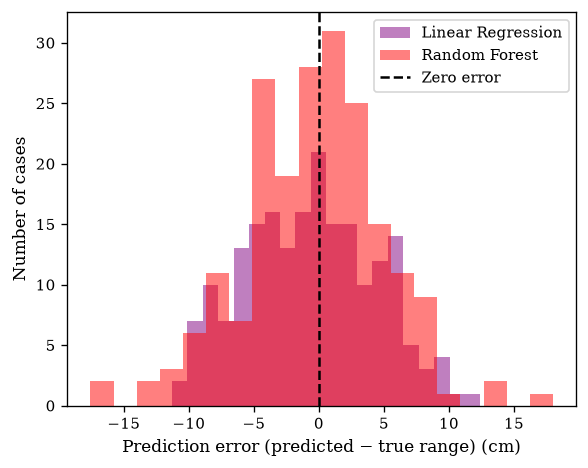

In [93]:
#Figure 4
plt.figure(figsize=(5, 4))
plt.hist(linear_error_5,bins=20,alpha=0.5,label="Linear Regression", color='purple')
plt.hist(rf_error_5,bins=20,alpha=0.5,label="Random Forest", color='red')
plt.axvline(0,linestyle="--", label='Zero error', color='black')

plt.xlabel("Prediction error (predicted − true range) (cm)")
plt.ylabel("Number of cases")
#plt.title("Range-prediction errors at 5% RSP uncertainty")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/figure_4_error_distribution.png",bbox_inches="tight")
plt.show()

Figure 4. Distribution of proton range-prediction errors at 5% RSP uncertainty. The physics-based predictions remain concentrated close to zero error, whereas both machine-learning models show substantially broader distributions.

In [71]:
#Summary of results
results_display

,Noise (%),Model,MAE (cm),RMSE (cm),R²,Max |error| (cm)
0,0,Physics baseline,0.000,0.000,1.000,0.000
1,0,Linear Regression,4.155,5.149,0.625,12.135
2,0,Random Forest,4.321,5.485,0.574,19.701
3,2,Physics baseline,0.018,0.045,1.000,0.200
4,2,Linear Regression,4.511,5.451,0.665,13.065
5,2,Random Forest,4.387,5.793,0.622,20.926
6,5,Physics baseline,0.057,0.095,1.000,0.500
7,5,Linear Regression,4.132,5.052,0.656,12.420
8,5,Random Forest,4.139,5.368,0.611,17.987


-Main findings-

The physics-based model remained highly accurate across all tested RSP uncertainty levels. At 5% RSP noise, its test-set MAE remained below 0.1 cm.

In contrast, Linear Regression and Random Forest produced MAEs of approximately 4–4.5 cm across the three noise conditions.

The machine-learning models already exhibited errors of approximately 4 cm in the absence of RSP noise. The ML error therefore cannot primarily be attributed to RSP uncertainty.

Instead, the results indicate that a major limitation is the reduction of each heterogeneous spatial RSP profile to five global summary features. Tissue ordering and spatial location influence proton energy loss, but this information is not retained by the ML representation.

The Random Forest did not substantially outperform Linear Regression, suggesting that increasing model non-linearity alone does not compensate for the missing spatial information.

-Limitations-

This study is a controlled computational benchmark rather than a clinical proton-therapy model.

The main limitations are:

- Synthetic one-dimensional tissue profiles rather than patient CT data.
- Simplified continuous slowing-down proton transport.
- Water stopping power scaled directly by local RSP.
- A spatial resolution of 0.1 cm.
- Simple global ML features that do not preserve spatial tissue structure.
- No modelling of nuclear interactions, scattering, range straggling, or other effects included in full Monte Carlo transport.
- No clinical validation.

-Future work-

Possible extensions include:

- Profile-aware machine-learning models such as one-dimensional convolutional neural networks or transformers.
- Physics-residual learning, where ML predicts corrections to a physics-based estimate rather than the full range directly.
- CT-derived RSP profiles and more realistic uncertainty models.
- Monte Carlo transport for higher-fidelity reference calculations.
- Evaluation using clinically relevant proton-beam configurations.

-Conclusion-

This study benchmarked simple machine-learning models against a physics-based proton range calculation under controlled RSP uncertainty.

The physics model substantially outperformed both Linear Regression and Random Forest across all tested uncertainty levels. The persistence of large ML errors even at 0% RSP noise indicates that the principal limitation was the loss of spatial information in the reduced feature representation rather than RSP uncertainty itself.

These results show the importance of incorporating spatial or physics-based information when applying machine learning to proton range prediction.